In [1]:
import sys
sys.path.append("/cellarold/users/mpagadal/Programs/anaconda3/envs/nagaenv/lib/python3.6/site-packages")
sys.path.append("/cellarold/users/mpagadal/Programs/anaconda3/lib/python3.7/site-packages")

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import networkx as nx
from ndex2.nice_cx_network import NiceCXNetwork 
import ndex2.client as nc
import ndex2

In [4]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from matplotlib_venn import venn3

In [5]:
import nbgwas
from nbgwas import Nbgwas
import numpy as np
import pandas as pd

## Gathering data

This package is flexible enough for nearly any GWAS summary statistics for any species, as long as the data is encoded in a table format.

In [6]:
group="eur"

In [7]:
snp_level_summary_url = '../data/summarystats/full/compiled.'+group+'.release4.testosterone.glm.linear'
protein_coding_url = '/cellar/users/mpagadal/resources/annotations/gencode.v19.annotation.gff3.geneonly'

snp_level_summary_df = pd.read_csv(snp_level_summary_url, delimiter="\t")
#snp_level_summary_df = tmp_snp_summary.rename(index=str, columns={"chromosome": "hg18chr", "basepair": "bp", "pvalue": "pval"})
protein_coding_df = pd.read_csv(protein_coding_url, sep='\t', header=None)

/cellar/users/mpagadal/Programs/miniconda3/envs/nagaenv/lib/python3.6/site-packages/IPython/core/interactiveshell.py:3072: DtypeWarning: Columns (0,4) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [8]:
protein_coding_df["gene"]=protein_coding_df[8].str.split("gene_name=").str[1]
protein_coding_df["gene"]=protein_coding_df["gene"].str.split(";").str[0]

In [9]:
protein_coding_df=protein_coding_df[["gene",0,3,4]]
protein_coding_df=protein_coding_df.set_index("gene")
protein_coding_df.columns=["Chrom","Start","End"]
protein_coding_df["Chrom"]=protein_coding_df["Chrom"].str.split("chr").str[1]

## Working with SNP and Genes Tables

Nbgwas requires two major components to work properly--gene level summary that contains p-values from genes, available from the Genes object, and a network that describes how the genes are connected, available from the Network objects. For genome wide association studies (GWAS), genomic information will be at the single nucleotide level. Nbgwas contains a class called Snps to handle this case.

To gain access to the these internal objects, first instantiate the Nbgwas client by calling the constructor. If you have gene level information in the form of pandas Dataframe and a network in either networkx or igraph object, you can provide these to the constructor as well. See the manual or use the help function for more information.

In [10]:
g = Nbgwas()

print(g.snps)
print(g.genes)
print(g.network)

<Snps> object
<Genes> object containing 0 genes


In [11]:
g = Nbgwas(
    snp_level_summary=snp_level_summary_df, 
    snp_chrom_col="#CHROM", 
    bp_col="POS", 
    snp_pval_col="P",
    
    protein_coding_table = protein_coding_df    
)

In [12]:
g.genes = g.snps.assign_snps_to_genes(window_size=10000, to_Gene=True)

In [13]:
g.genes.convert_to_heat(method='binarize', name='Binarized Heat')
g.genes.table.head()

,Gene,Chrom,Start-End,nSNPS,TopSNP P-Value,TopSNP Position,Binarized Heat
25178,NMNAT2,1,183217372-183387737,1061.0,2.007370e-06,183391147.0,1.0
14741,EVI2A,17,29644578-29648902,94.0,3.017850e-08,29654096.0,1.0
19610,KDM6B,17,7743222-7758114,195.0,4.474400e-28,7738526.0,1.0
13564,DISC1,1,231762561-232177018,2741.0,3.841140e-06,232177024.0,1.0
15642,FKBP4,12,2904119-2914576,155.0,2.726790e-43,2908330.0,1.0


In [14]:
g.genes.convert_to_heat(method='neg_log', name='Negative Log')
g.genes.table.head()

,Gene,Chrom,Start-End,nSNPS,TopSNP P-Value,TopSNP Position,Binarized Heat,Negative Log
49112,SHBG,17,7517382-7536700,236.0,2.916530e-162,7533015.0,1.0,371.948391
48564,SAT2,17,7529552-7531194,108.0,2.916530e-162,7533015.0,1.0,371.948391
1080,AC007421.1,17,7517264-7517427,95.0,3.345000e-154,7525001.0,1.0,353.390638
15963,FXR2,17,7494548-7518189,189.0,3.345000e-154,7525001.0,1.0,353.390638
23811,MPDU1,17,7486847-7496107,121.0,3.472330e-142,7504977.0,1.0,325.722257


In [15]:
g.network.from_ndex('f93f402c-86d4-11e7-a10d-0ac135e8bacf') #PCNet

In [16]:
g.network.node_table.head()

,name
0,UBE2Q1
1,RNF14
2,UBE2Q2
3,RNF10
4,RNF11


In [17]:
g.map_to_node_table(columns=['Binarized Heat', 'Negative Log'])
g.network.node_table.head()

,name,Binarized Heat,Negative Log
0,UBE2Q1,0.0,6.000836
1,RNF14,0.0,7.519116
2,UBE2Q2,0.0,5.388102
3,RNF10,0.0,4.673328
4,RNF11,0.0,6.496248


In [18]:
g.diffuse(method='random_walk', node_attribute='Binarized Heat', result_name='Diffused (Binarized)')
g.network.node_table.head()

/cellarold/users/mpagadal/Programs/anaconda3/envs/nagaenv/lib/python3.6/site-packages/nbgwas/propagation.py:57: UserWarning: Forcing F0 to be sparse
  warnings.warn("Forcing F0 to be sparse")


,name,Binarized Heat,Negative Log,Diffused (Binarized)
16804,TP53,1.0,192.034540,0.572107
6383,INS,1.0,12.466973,0.558652
4521,PCDHA10,1.0,14.507119,0.544204
3351,PCDHA3,1.0,14.507119,0.527566
10366,IGF2,1.0,12.466973,0.514578


In [19]:
g.diffuse(method='random_walk', node_attribute='Negative Log', result_name='Diffused (Log)')
g.network.node_table.head()

/cellarold/users/mpagadal/Programs/anaconda3/envs/nagaenv/lib/python3.6/site-packages/nbgwas/propagation.py:57: UserWarning: Forcing F0 to be sparse
  warnings.warn("Forcing F0 to be sparse")


,name,Binarized Heat,Negative Log,Diffused (Binarized),Diffused (Log)
8466,UBC,0.0,6.821917,0.412825,274.287639
3481,SHBG,1.0,371.948391,0.500121,174.601699
7090,SAT2,1.0,371.948391,0.446774,165.496332
19018,FXR2,1.0,353.390638,0.464343,162.314317
3859,EIF4A1,1.0,317.724983,0.476446,152.923431


In [20]:
g.diffuse(method='heat_diffusion', node_attribute='Negative Log', result_name='Diffused (Heat, Log)')
g.network.node_table.head()

,name,Binarized Heat,Negative Log,Diffused (Binarized),Diffused (Log),"Diffused (Heat, Log)"
7183,TDGF1P3,1.0,105.345289,0.440632,46.430756,95.961785
6504,RGAG1,1.0,105.173360,0.440425,46.374295,60.623182
1913,TMEM102,1.0,220.777158,0.441867,97.537631,35.546854
2596,TNFSF12-TNFSF13,1.0,312.042994,0.443948,138.669971,21.959726
18737,KCTD11,1.0,49.243284,0.442572,22.218373,20.899058


In [21]:
g.diffuse(method='heat_diffusion', node_attribute='Binarized Heat', result_name='Diffused (Heat, Binarize)')
g.network.node_table.head()

,name,Binarized Heat,Negative Log,Diffused (Binarized),Diffused (Log),"Diffused (Heat, Log)","Diffused (Heat, Binarize)"
7183,TDGF1P3,1.0,105.345289,0.440632,46.430756,95.961785,0.906744
18732,IFI27L1,1.0,18.463593,0.440778,8.154158,17.313353,0.906734
17278,KAL1,1.0,16.590127,0.440291,7.317119,15.622717,0.906474
8643,ZC3H12B,1.0,18.233247,0.449061,8.432011,16.125726,0.825424
12033,NPIPB9,1.0,16.187839,0.445841,7.295757,14.246298,0.824312


In [22]:
g.network.refresh_node_attributes()

In [23]:
g.network.node_table[g.network.node_table["Diffused (Binarized)"]==1]

,name,Binarized Heat,Negative Log,Diffused (Binarized),Diffused (Log),"Diffused (Heat, Log)","Diffused (Heat, Binarize)"


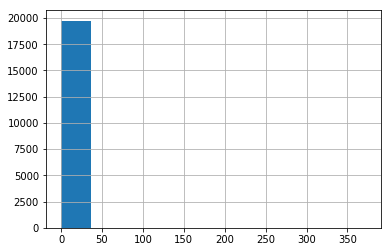

In [24]:
g.network.node_table["Negative Log"].hist()

In [25]:
len(g.network.node_table[g.network.node_table["Negative Log"]>50]["name"].tolist())

40

In [26]:
g.network.node_table.to_csv("../data/naga/"+group+".naga.tsv",index=None,sep="\t")

##### make network for European group

In [ ]:
g.network.to_ndex()
network = ndex2.create_nice_cx_from_networkx(g.network.network)
network.upload_to('public.ndexbio.org', 'meghanasp21', 'student16')

### Get NAGA genes

In [ ]:
eur=pd.read_csv("../data/naga/eur.naga.tsv",delimiter="\t")
afr=pd.read_csv("../data/naga/afr.naga.tsv",delimiter="\t")
his=pd.read_csv("../data/naga/his.naga.tsv",delimiter="\t")

In [ ]:
eur_genes=eur.sort_values(by="Negative Log",ascending=False)["name"].tolist()[0:50]
afr_genes=afr.sort_values(by="Negative Log",ascending=False)["name"].tolist()[0:50]
his_genes=his.sort_values(by="Negative Log",ascending=False)["name"].tolist()[0:50]

In [ ]:
venn3([set(eur_genes),set(afr_genes),set(his_genes)],
      set_labels=("eur","afr","his"), set_colors=["orange","blue","green"])
plt.savefig("../plots/naga.pdf")

In [ ]:
overlap=[x for x in eur_genes if x in afr_genes]
overlap=[x for x in overlap if x in his_genes]

In [ ]:
nodes=pd.DataFrame({"name":eur_genes+afr_genes+his_genes})

In [ ]:
nodes["name"].to_csv("../data/naga/nodes.txt",header=None,index=None)

In [ ]:
cytoscape=pd.read_csv("NAGA.testosterone.node.list.csv")
cytoscape["display"]=np.where(cytoscape["name"].isin(nodes["name"].tolist()),"yes","no")
cytoscape[["name","shared name","display"]].to_csv("../data/naga/nodes.csv",index=None)

In [ ]:
his_unique_genes=[x for x in his_genes if x not in eur_genes+afr_genes]
eur_unique_genes=[x for x in eur_genes if x not in his_genes+afr_genes]
afr_unique_genes=[x for x in afr_genes if x not in eur_genes+his_genes]

In [ ]:
len(his_unique_genes)

In [ ]:
len(afr_unique_genes)

In [ ]:
len(eur_unique_genes)

In [ ]:
cytoscape["group"]=np.where(cytoscape["name"].isin(overlap),"shared","intersect")
cytoscape["group"]=np.where(cytoscape["name"].isin(his_unique_genes),"his",cytoscape["group"])
cytoscape["group"]=np.where(cytoscape["name"].isin(eur_unique_genes),"eur",cytoscape["group"])
cytoscape["group"]=np.where(cytoscape["name"].isin(afr_unique_genes),"afr",cytoscape["group"])

In [ ]:
cytoscape[["name","shared name","group"]].to_csv("../naga/data/nodes.csv",index=None)

In [ ]:
../data/